In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("department_analysis.csv")
df.columns  # to decide features

Index(['department_id', 'department_name', 'location', 'annual_budget',
       'base_wait_days', 'manual_workload_multiplier', 'claim_denial_risk',
       'lab_delay_risk', 'total_manual_minutes', 'avg_manual_minutes',
       'task_count', 'error_rate', 'avg_overbooking', 'strain_rate',
       'provider_count', 'avg_wait_days', 'noshow_rate', 'appt_count'],
      dtype='str')

In [12]:
print(df[X].dtypes)

print(df.head())

task_count                      int64
appt_count                      int64
provider_count                  int64
total_manual_minutes          float64
avg_manual_minutes            float64
manual_workload_multiplier    float64
avg_wait_days                 float64
error_rate                    float64
avg_overbooking               float64
noshow_rate                   float64
strain_rate                   float64
claim_denial_risk             float64
lab_delay_risk                float64
dtype: object
  department_id department_name          location  annual_budget  \
0          D001      Cardiology       Main Campus     2494683.86   
1          D002        Oncology         East Wing     4388388.17   
2          D003       Neurology       Main Campus     3995981.05   
3          D004       Emergency  Satellite Clinic     2112350.96   
4          D005       Radiology         West Wing     3932157.40   

   base_wait_days  manual_workload_multiplier  claim_denial_risk  \
0              

In [50]:
# Prepare features (dropping ID and hidden segment)
cluster_features = [
    "task_count",
    "appt_count",
    "provider_count",
    "total_manual_minutes",
    "avg_manual_minutes",
    "manual_workload_multiplier",
    "avg_wait_days",
    "error_rate",
    "avg_overbooking",
    "noshow_rate",
    "strain_rate",
    "claim_denial_risk",
    "lab_delay_risk"
]

X = df[cluster_features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Attach cluster labels back to dataframe
df["cluster"] = clusters

# Cluster sizes
print("Cluster sizes:\n", df["cluster"].value_counts().sort_index())

# Cluster profiles
print("\nCluster profiles:\n",
      df.groupby("cluster")[cluster_features].mean().round(2))

Cluster sizes:
 cluster
0    27
1     4
2    19
Name: count, dtype: int64

Cluster profiles:
          task_count  appt_count  provider_count  total_manual_minutes  \
cluster                                                                 
0           9001.48    18335.44           36.96             369631.99   
1           8903.25    19815.00           40.00             864963.88   
2           8955.16    21933.89           44.32             366684.31   

         avg_manual_minutes  manual_workload_multiplier  avg_wait_days  \
cluster                                                                  
0                     41.05                        1.20          15.11   
1                     97.08                        2.86          27.24   
2                     40.91                        1.20          33.58   

         error_rate  avg_overbooking  noshow_rate  strain_rate  \
cluster                                                          
0              0.07             1.08 

C:\Users\Admin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


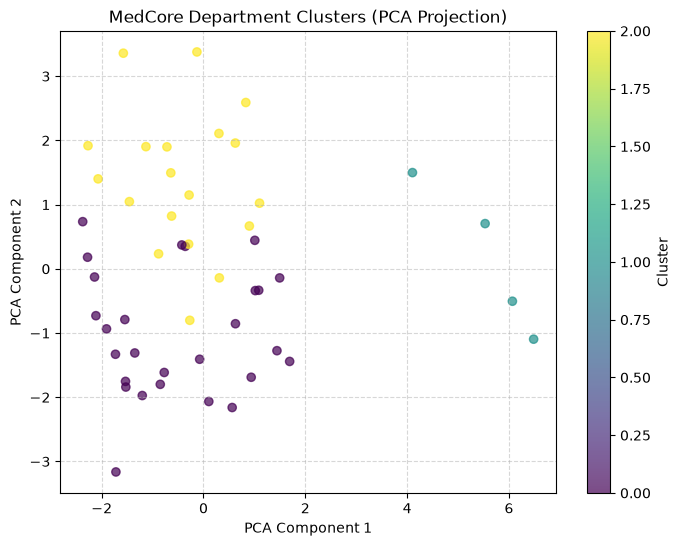

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df["pca1"], df["pca2"], c=df["cluster"], cmap="viridis", alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("MedCore Department Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

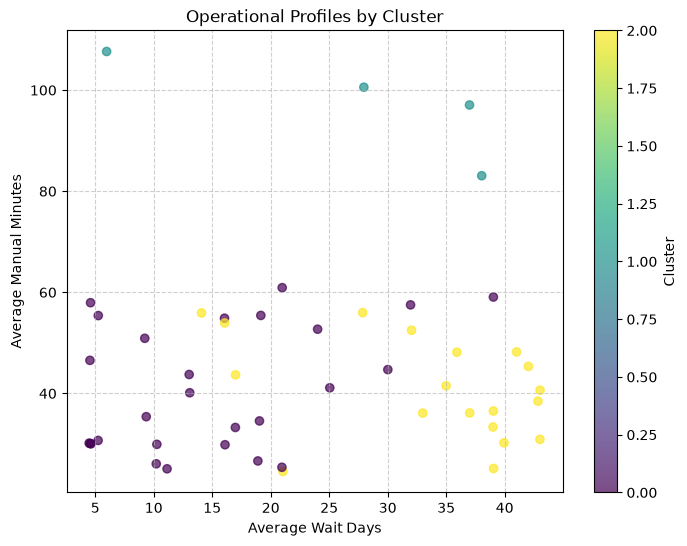

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(df["avg_wait_days"], df["avg_manual_minutes"],
            c=df["cluster"], cmap="viridis", alpha=0.7)

plt.xlabel("Average Wait Days")
plt.ylabel("Average Manual Minutes")
plt.title("Operational Profiles by Cluster")
plt.colorbar(label="Cluster")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [54]:
cluster_summary = df.groupby("cluster")[[
    "avg_wait_days",
    "avg_manual_minutes",
    "error_rate",
    "appt_count"
]].mean()

**Cluster 0 — Standard Operations / Balanced Departments (n = 27)**

Features: 
 - Mid-range wait times
 - Moderate workload
 - Stable error and strain rates

Interpretation: These departments operate close to system norms with no extreme bottlenecks or inefficiencies.

**Cluster 1 — High-Complexity / Process Breakdown Departments (n = 4)**

Features:
 - Extremely high manual effort (~97 min)
 - Very high workload multiplier
 - Elevated error rate
 - Long waits despite not highest volume

Interpretation: These are structurally complex departments where processes are inefficient and error-prone, likely requiring workflow redesign or automation.

**Cluster 2 — High Demand / Access Bottleneck Departments (n = 19)**

Features:
 - Highest wait times (33.6 days)
 - Highest appointment volume
 - High no-show rate
 - Moderate efficiency metrics

Interpretation: These departments are primarily constrained by demand exceeding capacity, leading to access delays rather than internal inefficiency.